# Medical Cost prediction Notebook

## Dataset importing 

In [1]:
import pandas as pd
import os 
cur=os.getcwd()
bas_dir=os.path.dirname(cur)
path=os.path.join(bas_dir,'data','insurance.csv')
df=pd.read_csv(path)

## Analysis

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.shape

(1338, 7)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
#Checking Missing values
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- There is no missing values

## Analysis

<Axes: xlabel='charges', ylabel='Count'>

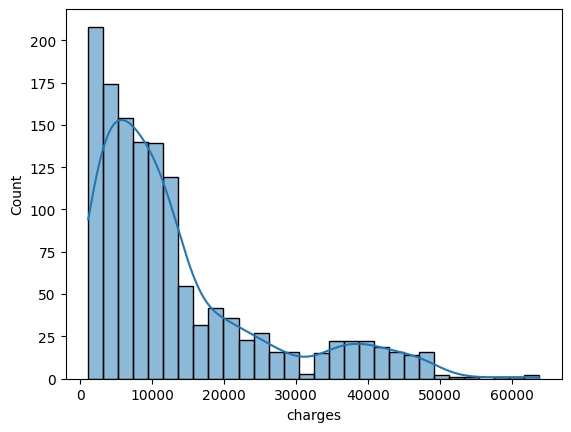

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['charges'],kde='True')

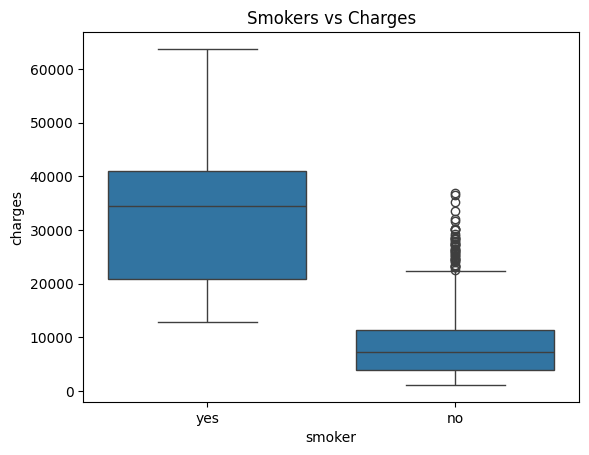

In [10]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title('Smokers vs Charges')
plt.show()


Smokers vs charges Insight
- The above Figure shows that the smokers have a higher charges compare to non smokers

Text(0.5, 1.0, 'Age VS Charges')

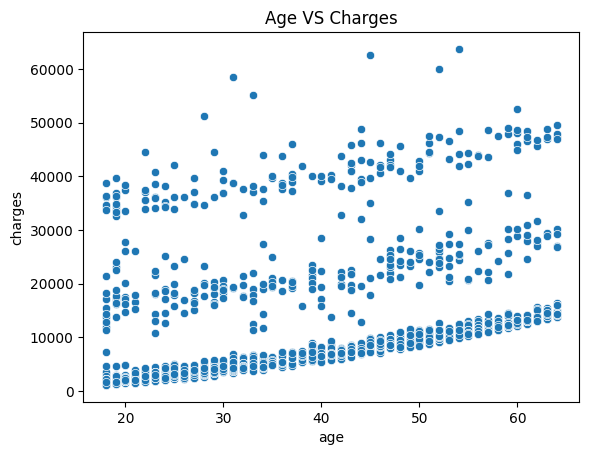

In [11]:
# Age vs charges
sns.scatterplot(x='age',y='charges',data=df)
plt.title('Age VS Charges')

Text(0.5, 1.0, 'Bmi VS charges')

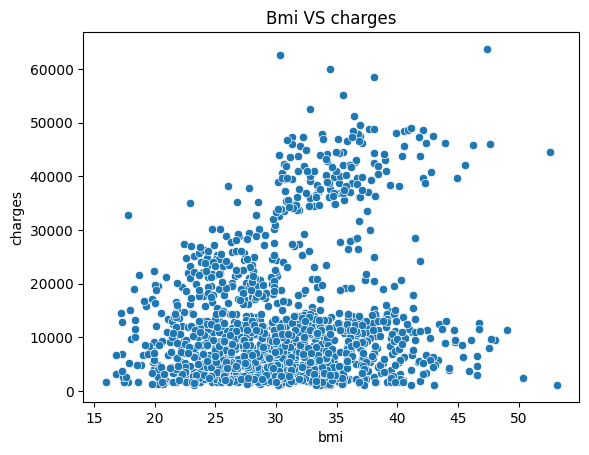

In [12]:
sns.scatterplot(x='bmi',y='charges',data=df)
plt.title('Bmi VS charges')

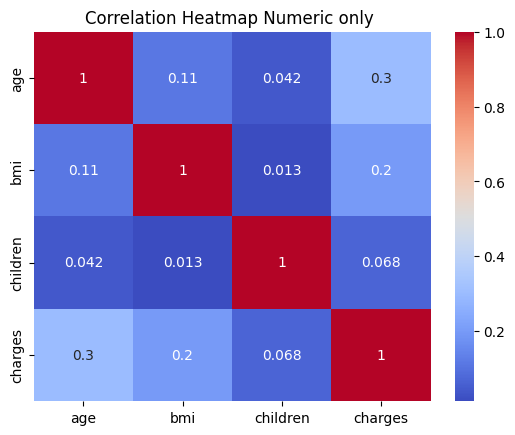

In [13]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap Numeric only ')
plt.show()

In [14]:
#one-hot encoding
df=pd.get_dummies(df,drop_first=True)

One-Hot Encoding

- Categorical variables such as sex, smoker, and region were converted into numerical format using one-hot encoding.

- This was necessary because machine learning models require numerical input and cannot directly process categorical data.

- One-hot encoding was specifically chosen to avoid introducing any ordinal relationship between categories. For example, assigning values like 0, 1, 2 to categories such as regions would incorrectly imply an order, which does not exist.

- Therefore, one-hot encoding ensures that each category is treated independently without adding misleading relationships.

In [47]:
df = df.astype(int)

age                 int64
bmi                 int64
children            int64
charges             int64
sex_male            int64
smoker_yes          int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object